In [8]:
import os
import cv2
import shutil
import random
import time
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Cell 2: Create a Smaller Dataset Subset

In [9]:
train_dir = r"D:\Ali Garrab\day_5\data\train"
subset_dir = r"D:\Ali Garrab\day_5\data\cats_vs_dogs_subset"

# Clean up old subset directory if it exists to start fresh
if os.path.exists(subset_dir):
    shutil.rmtree(subset_dir)

random.seed(42)

# Locate all labeled cat and dog images
items = os.listdir(train_dir)
if "cats" in items and "dogs" in items:
    cats_src = os.path.join(train_dir, "cats")
    dogs_src = os.path.join(train_dir, "dogs")
    cats_files = [os.path.join(cats_src, f) for f in os.listdir(cats_src)]
    dogs_files = [os.path.join(dogs_src, f) for f in os.listdir(dogs_src)]
else:
    cats_files = [os.path.join(train_dir, f) for f in os.listdir(train_dir) if "cat" in f.lower()]
    dogs_files = [os.path.join(train_dir, f) for f in os.listdir(train_dir) if "dog" in f.lower()]

# Shuffle to prevent bias
random.shuffle(cats_files)
random.shuffle(dogs_files)

# Train: 1,000 cats + 1,000 dogs (2,000 total)
# Test:    500 cats +   500 dogs (1,000 total)
train_cats, test_cats = cats_files[:1000], cats_files[1000:1500]
train_dogs, test_dogs = dogs_files[:1000], dogs_files[1000:1500]

def copy_files(file_list, split, category):
    dest_folder = os.path.join(subset_dir, split, category)
    os.makedirs(dest_folder, exist_ok=True)
    for f in file_list:
        shutil.copy2(f, os.path.join(dest_folder, os.path.basename(f)))
    print(f"[{split.upper()}] Saved {len(file_list)} {category} -> {dest_folder}")

# Copy files into subset directory
copy_files(train_cats, "train", "cats")
copy_files(train_dogs, "train", "dogs")
copy_files(test_cats, "test", "cats")
copy_files(test_dogs, "test", "dogs")

print("\n✅ Subset creation complete!")

[TRAIN] Saved 1000 cats -> D:\Ali Garrab\day_5\data\cats_vs_dogs_subset\train\cats
[TRAIN] Saved 1000 dogs -> D:\Ali Garrab\day_5\data\cats_vs_dogs_subset\train\dogs
[TEST] Saved 500 cats -> D:\Ali Garrab\day_5\data\cats_vs_dogs_subset\test\cats
[TEST] Saved 500 dogs -> D:\Ali Garrab\day_5\data\cats_vs_dogs_subset\test\dogs

✅ Subset creation complete!


Cell 3: Feature Extraction Functions

In [19]:
def extract_raw_pixels(image, size=(64, 64)):
    """Representation A: Raw resized BGR/RGB pixels flattened into a 1D vector."""
    resized = cv2.resize(image, size)
    return resized.flatten() #

def extract_color_stats_edges(image, size=(128, 128)):
    """Representations B, C, D: Grayscale stats, RGB histograms, and Edge densities."""
    resized = cv2.resize(image, size)
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    
    features = []
    feature_names = []
    
    # 1. Statistical Features
    features.extend([np.mean(gray), np.std(gray), np.min(gray), np.max(gray), np.median(gray)])
    feature_names.extend(['mean_intensity', 'std_intensity', 'min_intensity', 'max_intensity', 'median_intensity'])
    
    # 2. Color Histograms (R, G, B) - 32 bins each
    for i, color in enumerate(['B', 'G', 'R']):
        hist = cv2.calcHist([resized], [i], None, [32], [0, 256]).flatten()
        features.extend(hist)
        feature_names.extend([f'{color}_hist_bin_{j}' for j in range(32)])
        
    # 3. Edge Features
    edges = cv2.Canny(gray, 100, 200)
    edge_density = np.sum(edges > 0) / edges.size
    features.append(edge_density)
    feature_names.append('edge_density_canny')
    
    # Horizontal & Vertical Edge Densities (Sobel)
    sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    features.append(np.sum(np.abs(sobel_x)) / gray.size)
    feature_names.append('horizontal_edge_density')
    features.append(np.sum(np.abs(sobel_y)) / gray.size)
    feature_names.append('vertical_edge_density')
    
    return np.array(features), feature_names

def extract_hog(image, size=(128, 128)):
    """Representation E: Histogram of Oriented Gradients (HOG) descriptor."""
    resized = cv2.resize(image, size)
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    features = hog(gray, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2)) #
    return features

Cell 4: Dataset Processing & Feature Extraction

In [20]:
# Cell 4: Dataset Processing & Feature Extraction
def load_and_extract(base_folder):
    X_raw, X_stats, X_hog, y = [], [], [], []
    classes = ['cats', 'dogs']
    stats_feature_names = None
    
    for label_idx, class_name in enumerate(classes):
        folder_path = os.path.join(base_folder, class_name)
        if not os.path.exists(folder_path):
            print(f"⚠️ Warning: Folder not found -> {folder_path}")
            continue
            
        for filename in os.listdir(folder_path):
            img_path = os.path.join(folder_path, filename)
            image = cv2.imread(img_path)
            
            if image is not None:
                X_raw.append(extract_raw_pixels(image))
                
                stats, names = extract_color_stats_edges(image)
                X_stats.append(stats)
                if stats_feature_names is None:
                    stats_feature_names = names
                    
                X_hog.append(extract_hog(image))
                y.append(label_idx)
                
    return np.array(X_raw), np.array(X_stats), np.array(X_hog), np.array(y), stats_feature_names

print("Processing Training Data...")
X_train_raw, X_train_stats, X_train_hog, y_train, feature_names = load_and_extract(r'D:\Ali Garrab\day_5\data\cats_vs_dogs_subset\train')
print(f"--> Loaded {len(y_train)} training images.")

print("Processing Testing Data...")
X_test_raw, X_test_stats, X_test_hog, y_test, _ = load_and_extract(r'D:\Ali Garrab\day_5\data\cats_vs_dogs_subset\test')
print(f"--> Loaded {len(y_test)} testing images.")

if len(y_train) == 0 or len(y_test) == 0:
    print("\n❌ ERROR: No images were loaded. Check your folder paths before running Cell 5!")
else:
    print("\n✅ Extraction complete!")
    print(f"Data shapes -> Raw: {X_train_raw.shape}, Stats/Colors: {X_train_stats.shape}, HOG: {X_train_hog.shape}")

Processing Training Data...
--> Loaded 2000 training images.
Processing Testing Data...
--> Loaded 1000 testing images.

✅ Extraction complete!
Data shapes -> Raw: (2000, 12288), Stats/Colors: (2000, 104), HOG: (2000, 8100)


Cell 5: Feature Scaling

In [21]:
scaler_raw = StandardScaler()
X_train_raw_s = scaler_raw.fit_transform(X_train_raw)
X_test_raw_s = scaler_raw.transform(X_test_raw)

scaler_stats = StandardScaler()
X_train_stats_s = scaler_stats.fit_transform(X_train_stats)
X_test_stats_s = scaler_stats.transform(X_test_stats)

scaler_hog = StandardScaler()
X_train_hog_s = scaler_hog.fit_transform(X_train_hog)
X_test_hog_s = scaler_hog.transform(X_test_hog)

print("✅ All feature representations scaled successfully.")

✅ All feature representations scaled successfully.


Cell 6: Experiment 1 — Raw Pixels (MLP vs. SVM)

In [15]:
print("==========================================")
print("--- Experiment 1: Raw Pixels ---")
print("==========================================")

# 1. MLP Classifier
mlp_raw = MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu", max_iter=100, random_state=42)
t0 = time.time()
mlp_raw.fit(X_train_raw_s, y_train)
mlp_raw_time = time.time() - t0
mlp_raw_preds = mlp_raw.predict(X_test_raw_s)
mlp_raw_acc = accuracy_score(y_test, mlp_raw_preds)

print(f"MLP (Raw) - Time: {mlp_raw_time:.2f}s | Accuracy: {mlp_raw_acc:.4f}")

# 2. SVM Classifier
svm_raw = SVC(kernel='rbf', random_state=42)
t0 = time.time()
svm_raw.fit(X_train_raw_s, y_train)
svm_raw_time = time.time() - t0
svm_raw_preds = svm_raw.predict(X_test_raw_s)
svm_raw_acc = accuracy_score(y_test, svm_raw_preds)

print(f"SVM (Raw) - Time: {svm_raw_time:.2f}s | Accuracy: {svm_raw_acc:.4f}")

--- Experiment 1: Raw Pixels ---
MLP (Raw) - Time: 23.55s | Accuracy: 0.5990
SVM (Raw) - Time: 391.29s | Accuracy: 0.6250


Cell 6.5: Experiment 1B — Grayscale Raw Pixels

In [22]:
# Cell 6.5: Experiment 1B — Grayscale Raw Pixels
print("==========================================")
print("--- Experiment 1B: Grayscale Raw Pixels ---")
print("==========================================")

# 1. Quick extraction specifically for grayscale
def load_grayscale_raw(base_folder, size=(64, 64)):
    X, y = [], []
    for label_idx, class_name in enumerate(['cats', 'dogs']):
        folder_path = os.path.join(base_folder, class_name)
        if not os.path.exists(folder_path): continue
        for filename in os.listdir(folder_path):
            img_path = os.path.join(folder_path, filename)
            img = cv2.imread(img_path)
            if img is not None:
                gray = cv2.cvtColor(cv2.resize(img, size), cv2.COLOR_BGR2GRAY)
                X.append(gray.flatten())
                y.append(label_idx)
    return np.array(X), np.array(y)

print("Extracting Grayscale pixels...")
X_train_gray, y_train_gray = load_grayscale_raw(r'D:\Ali Garrab\day_5\data\cats_vs_dogs_subset\train')
X_test_gray, y_test_gray = load_grayscale_raw(r'D:\Ali Garrab\day_5\data\cats_vs_dogs_subset\test')
print(f"New feature vector dimensionality: {X_train_gray.shape[1]} (Down from 12288)")

# 2. Scale the grayscale data
scaler_gray = StandardScaler()
X_train_gray_s = scaler_gray.fit_transform(X_train_gray)
X_test_gray_s = scaler_gray.transform(X_test_gray)

# 3. Train MLP
mlp_gray = MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu", max_iter=100, random_state=42)
t0 = time.time()
mlp_gray.fit(X_train_gray_s, y_train_gray)
mlp_gray_time = time.time() - t0
mlp_gray_acc = accuracy_score(y_test_gray, mlp_gray.predict(X_test_gray_s))
print(f"MLP (Grayscale) - Time: {mlp_gray_time:.2f}s | Accuracy: {mlp_gray_acc:.4f}")

# 4. Train SVM
svm_gray = SVC(kernel='rbf', random_state=42)
t0 = time.time()
svm_gray.fit(X_train_gray_s, y_train_gray)
svm_gray_time = time.time() - t0
svm_gray_acc = accuracy_score(y_test_gray, svm_gray.predict(X_test_gray_s))
print(f"SVM (Grayscale) - Time: {svm_gray_time:.2f}s | Accuracy: {svm_gray_acc:.4f}")

--- Experiment 1B: Grayscale Raw Pixels ---
Extracting Grayscale pixels...
New feature vector dimensionality: 4096 (Down from 12288)
MLP (Grayscale) - Time: 8.91s | Accuracy: 0.5790
SVM (Grayscale) - Time: 6.06s | Accuracy: 0.6220


Cell 7: Experiment 2 — Color, Stats & Edge Features (MLP vs. SVM)

In [23]:
print("==========================================")
print("--- Experiment 2: Color, Stats & Edge Features ---")
print("==========================================")

# 1. MLP Classifier
mlp_stats = MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu", max_iter=100, random_state=42)
t0 = time.time()
mlp_stats.fit(X_train_stats_s, y_train)
mlp_stats_time = time.time() - t0
mlp_stats_preds = mlp_stats.predict(X_test_stats_s)
mlp_stats_acc = accuracy_score(y_test, mlp_stats_preds)

print(f"MLP (Stats) - Time: {mlp_stats_time:.2f}s | Accuracy: {mlp_stats_acc:.4f}")

# 2. SVM Classifier
svm_stats = SVC(kernel='rbf', random_state=42)
t0 = time.time()
svm_stats.fit(X_train_stats_s, y_train)
svm_stats_time = time.time() - t0
svm_stats_preds = svm_stats.predict(X_test_stats_s)
svm_stats_acc = accuracy_score(y_test, svm_stats_preds)

print(f"SVM (Stats) - Time: {svm_stats_time:.2f}s | Accuracy: {svm_stats_acc:.4f}")

--- Experiment 2: Color, Stats & Edge Features ---


d:\Ali Garrab\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP (Stats) - Time: 0.70s | Accuracy: 0.6040
SVM (Stats) - Time: 0.10s | Accuracy: 0.6480


Cell 8: Experiment 3 — HOG Features (MLP vs. SVM)

In [24]:
print("==========================================")
print("--- Experiment 3: HOG Features ---")
print("==========================================")

# 1. MLP Classifier
mlp_hog = MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu", max_iter=100, random_state=42)
t0 = time.time()
mlp_hog.fit(X_train_hog_s, y_train)
mlp_hog_time = time.time() - t0
mlp_hog_preds = mlp_hog.predict(X_test_hog_s)
mlp_hog_acc = accuracy_score(y_test, mlp_hog_preds)

print(f"MLP (HOG) - Time: {mlp_hog_time:.2f}s | Accuracy: {mlp_hog_acc:.4f}")

# 2. SVM Classifier
svm_hog = SVC(kernel='rbf', random_state=42)
t0 = time.time()
svm_hog.fit(X_train_hog_s, y_train)
svm_hog_time = time.time() - t0
svm_hog_preds = svm_hog.predict(X_test_hog_s)
svm_hog_acc = accuracy_score(y_test, svm_hog_preds)

print(f"SVM (HOG) - Time: {svm_hog_time:.2f}s | Accuracy: {svm_hog_acc:.4f}")

--- Experiment 3: HOG Features ---
MLP (HOG) - Time: 8.79s | Accuracy: 0.7010
SVM (HOG) - Time: 17.27s | Accuracy: 0.7130


Cell 9: Feature Importance & Analysis

--- Top 15 Most Helpful Individual Features ---
 1. horizontal_edge_density  : 0.0303
 2. vertical_edge_density    : 0.0271
 3. edge_density_canny       : 0.0235
 4. G_hist_bin_1             : 0.0181
 5. G_hist_bin_2             : 0.0159
 6. B_hist_bin_9             : 0.0116
 7. B_hist_bin_7             : 0.0115
 8. B_hist_bin_8             : 0.0113
 9. R_hist_bin_10            : 0.0111
10. B_hist_bin_1             : 0.0110
11. G_hist_bin_3             : 0.0109
12. B_hist_bin_19            : 0.0108
13. R_hist_bin_2             : 0.0107
14. B_hist_bin_10            : 0.0107
15. G_hist_bin_7             : 0.0107


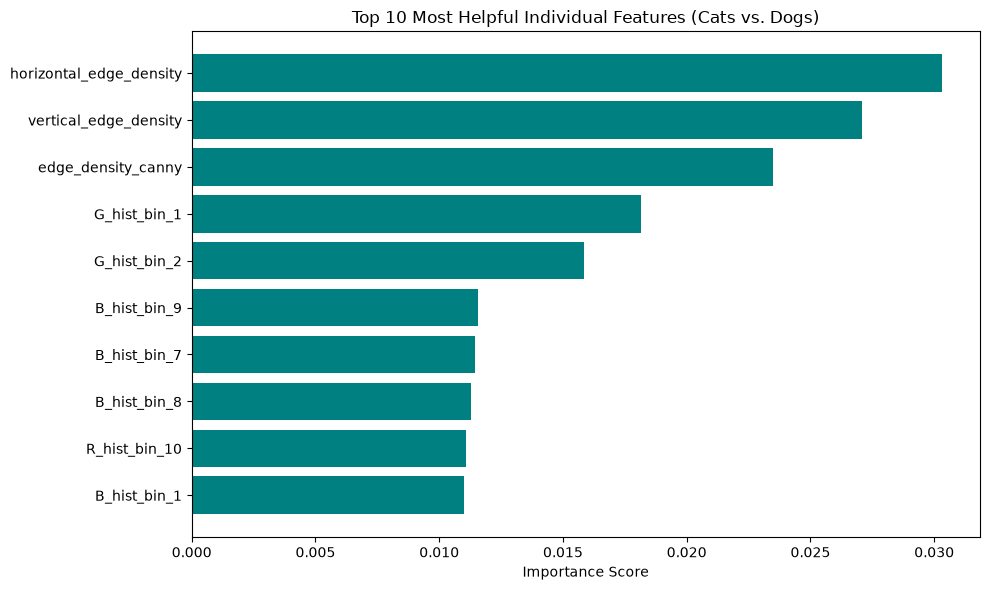


             SUMMARY COMPARISON TABLE                     
Feature Type         | MLP Accuracy | SVM Accuracy
----------------------------------------------------
Raw Pixels (RGB)     | 0.5990       | 0.6250      
Raw Pixels (Gray)    | 0.5790       | 0.6220      
Stats/Colors/Edges   | 0.6040       | 0.6480      
HOG Features         | 0.7010       | 0.7130      


In [26]:
# 1. Train a Random Forest to rank explicit feature importances (Stats/Color/Edges)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_stats_s, y_train)

importances = rf.feature_importances_
feature_ranking = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)

print("--- Top 15 Most Helpful Individual Features ---")
for rank, (name, importance) in enumerate(feature_ranking[:15], 1):
    print(f"{rank:2d}. {name:<25}: {importance:.4f}")

# 2. Plot top 10 individual features
top_names = [x[0] for x in feature_ranking[:10]]
top_scores = [x[1] for x in feature_ranking[:10]]

plt.figure(figsize=(10, 6))
plt.barh(top_names[::-1], top_scores[::-1], color='teal')
plt.xlabel("Importance Score")
plt.title("Top 10 Most Helpful Individual Features (Cats vs. Dogs)")
plt.tight_layout()
plt.show()

# 3. Comprehensive Summary Comparison Table (Including Grayscale)
print("\n==========================================================")
print("             SUMMARY COMPARISON TABLE                     ")
print("==========================================================")
print(f"{'Feature Type':<20} | {'MLP Accuracy':<12} | {'SVM Accuracy':<12}")
print("-" * 52)
print(f"{'Raw Pixels (RGB)':<20} | {mlp_raw_acc:<12.4f} | {svm_raw_acc:<12.4f}")

# Fallback check in case mlp_gray_acc was not run in Cell 6.5 yet
if 'mlp_gray_acc' in globals() and 'svm_gray_acc' in globals():
    print(f"{'Raw Pixels (Gray)':<20} | {mlp_gray_acc:<12.4f} | {svm_gray_acc:<12.4f}")

print(f"{'Stats/Colors/Edges':<20} | {mlp_stats_acc:<12.4f} | {svm_stats_acc:<12.4f}")
print(f"{'HOG Features':<20} | {mlp_hog_acc:<12.4f} | {svm_hog_acc:<12.4f}")
print("==========================================================")